In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import pandas as pd
import hbn_pl.io as io
import hbn_pl.preprocess as preprocess
import hbn_pl.plot as plot
import hbn_pl.peaks as peaks

good_emitters = []
review_log = []

def review_prompt(current_index: int, total: int) -> tuple[str, bool]:
    '''
    Prompt the user to review the current emitter and choose an action.
    
    Args:
        current_index: The index of the current emitter being reviewed (0-based)
        total: The total number of emitters in the batch

    Returns:
        A tuple containing:
        - action: A string indicating the user's choice ("save", "skip", "back", "quit")
        - good_flag: A boolean indicating whether the emitter was marked as good (True if "g" was chosen, False otherwise)
    '''
    # Graphical progress bar
    bar_length = 30
    progress = (current_index + 1) / total
    filled_length = int(bar_length * progress)
    bar = "█" * filled_length + "-" * (bar_length - filled_length)
    percent = int(progress * 100)
    print(f"Progress: |{bar}| {percent}% ({current_index + 1}/{total} emitters)\n")

    # Command options
    print("Options:")
    print("ENTER → Save")
    print("s     → Skip")
    print("g     → Mark good emitter + save")
    print("b     → Go back to previous emitter")
    print("q     → Quit batch")
    
    user = input("Choice: ").strip().lower()
    
    if user == "":
        return "save", False
    elif user == "s":
        return "skip", False
    elif user == "g":
        return "save", True
    elif user == "b":
        return "back", False
    elif user == "q":
        return "quit", False
    else:
        return "save", False

def save_csvs(directory: Path) -> None:
    '''
    Save the review log and good emitters list to CSV files in the specified directory.

    Args:
        directory: Path to the directory where the CSV files will be saved

    Returns:
        None (saves CSV files to disk)
    '''
    if review_log:
        df_log = pd.DataFrame(review_log)
        df_log.to_csv(directory / "review_log.csv", index=False)
    if good_emitters:
        df_good = pd.DataFrame({"good_emitters": good_emitters})
        df_good.to_csv(directory / "good_emitters.csv", index=False)

def process_spe_file(spe_path: Path, wait_for_confirm: bool=True, current_index: int=0, total: int=0) -> tuple[str, bool, float, np.ndarray, np.ndarray, plt.Figure]:
    '''
    Process a single .spe file to extract the spectrum, estimate the ZPL, and plot the energy spectrum. Optionally prompts the user for review.

    Args:
        spe_path: Path to the .spe file to be processed
        wait_for_confirm: If True, prompts the user to review the results and choose an action
        current_index: The index of the current emitter being processed (for progress display)
        total: The total number of emitters in the batch (for progress display)
    
    Returns:
        A tuple containing:
        - action: A string indicating the user's choice ("save", "skip", "back", "quit")
        - good_flag: A boolean indicating whether the emitter was marked as good (True if "g" was chosen, False otherwise)
        - zpl_wavelength: The estimated ZPL wavelength in nm
        - intensity: The intensity values of the spectrum
        - energy: The energy values corresponding to the spectrum
        - figure: The matplotlib figure object containing the energy plot
    '''
    
    global good_emitters, review_log

    print(f"\nProcessing: {spe_path.name}")

    wavelength, frames = io.load_spe(spe_path)

    # Background subtraction
    frames = preprocess.background_subtract(frames, bg_slice=(1, 50))

    # Cosmic ray detection
    cosmic_frames, cosmic_location = preprocess.detect_cosmic_frames(
        frames, wavelength,
        prominence_threshold=0.05,
        fwhm_threshold=1.9,
        n_peaks=3,
        z_thresh=100,
        half_width=5,
        noise_width=30
    )

    plot.plot_cosmic_frames(frames, wavelength, cosmic_location)

    frames_cleaned, cosmic_figs = preprocess.remove_cosmic_rays(
        frames, wavelength,
        cosmic_frames, cosmic_location,
        sigma=1.5, half_width=5
    )

    frames = frames_cleaned

    # Remove bad frames
    drop_fraction = 0.6
    bad_frames = preprocess.detect_bad_frames_simple(frames, drop_fraction=drop_fraction)
    frames = preprocess.remove_frames(frames, bad_frames)

    # Average and normalize
    avg, avg_norm = preprocess.average_and_normalise(frames)
    plot.plot_spectrum(x=wavelength, spectrum=avg_norm, x_quantity='Wavelength (nm)')

    # Estimate ZPL
    max_index = np.argmax(avg_norm)
    zpl_wavelength = wavelength[max_index]
    print("Estimated ZPL:", zpl_wavelength)
    corrected_spectrum = avg_norm

    # Energy plot
    intensity, energy, figure = plot.plot_energy(wavelength, corrected_spectrum, zpl_wavelength)
    figure.canvas.draw()
    plt.show(block=False)
    plt.pause(0.1)

    # Review prompt
    if wait_for_confirm:
        action, good_flag = review_prompt(current_index, total)
        return action, good_flag, zpl_wavelength, intensity, energy, figure
    else:
        return "save", False, zpl_wavelength, intensity, energy, figure


def batch_process(directory: Path, wait_for_confirm: bool=True) -> None:
    '''
    Process a batch of .spe files in the specified directory, allowing the user to review each emitter and choose actions. 
    Saves results and logs to CSV files.

    Args:
        directory: Path to the directory containing the .spe files
        wait_for_confirm: If True, prompts the user to review each emitter and choose actions. If False, processes all files and saves results without prompting.
    
    Returns:
        None (saves results and logs to CSV files in the specified directory)
    '''
    global good_emitters, review_log

    spe_files = sorted(directory.glob("*.spe"))
    total_files = len(spe_files)
    print(f"Found {total_files} .spe files")

    i = 0
    while i < total_files:
        clear_output(wait=True)
        plt.close('all')

        spe_path = spe_files[i]
        action, good_flag, zpl_wavelength, intensity, energy, figure = process_spe_file(
            spe_path,
            wait_for_confirm=wait_for_confirm,
            current_index=i,
            total=total_files
        )

        if action == "quit":
            print("User aborted batch processing.")
            break

        if action == "back":
            if i > 0:
                i -= 1
                # Remove last log entry if exists
                if review_log:
                    last_entry = review_log.pop()
                    if last_entry["good_emitter"] and last_entry["file"] in good_emitters:
                        good_emitters.remove(last_entry["file"])
                continue
            else:
                print("Already at the first emitter!")
                continue

        # Record decision
        review_log.append({
            "file": spe_path.name,
            "action": action,
            "good_emitter": good_flag,
            "zpl_nm": zpl_wavelength
        })

        if good_flag:
            good_emitters.append(spe_path.name)
            print("⭐ Marked as good emitter")

        # Save CSVs incrementally
        save_csvs(directory)
        print("✅ Review log updated.")

        # Save processed results if not skipped
        if action != "skip":
            io.save_preprocess_results(spe_path, intensity, energy, figure, zpl_wavelength)
            print(f"\nSaved results for file: {spe_path.name}")
        else:
            print(f"\nSkipped saving for file: {spe_path.name}")

        i += 1

    print("\nBatch processing complete.")
    print(f"Review log saved at: {directory / 'review_log.csv'}")
    print(f"Good emitters saved at: {directory / 'good_emitters.csv'}")


Processing: 2026 January 23 15_32_39 Sample7_uncapped_500uW_grating150_exposure20_emitter 96_2.spe
Performing background subtraction...
Successfully subtracted background.
Detecting cosmic ray frames...
Only one frame detected — skipping cosmic ray detection.
Removing cosmic rays from 0 frames: []
Running simple bad frame detection...
Only one frame detected — skipping bad frame detection.
Removing 0 frames: []
Averaging and normalising frames into a single spectrum...
Successfully averaged and normalised frames.


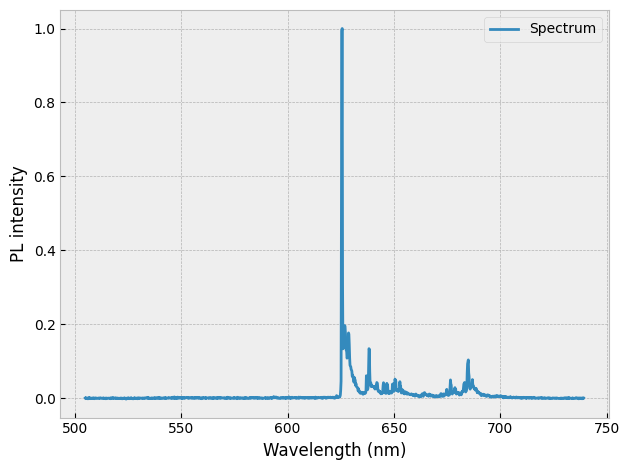

Estimated ZPL: 625.6734916582234


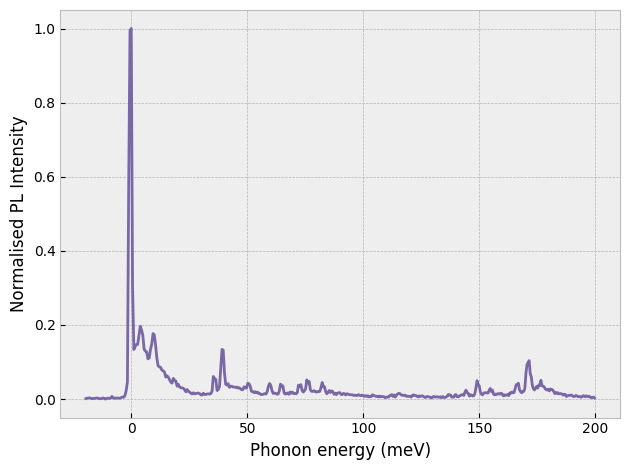

Progress: |██████████████████████████████| 100% (117/117 emitters)

Options:
ENTER → Save
s     → Skip
g     → Mark good emitter + save
b     → Go back to previous emitter
q     → Quit batch
⭐ Marked as good emitter
✅ Review log updated.
Saved: C:\Users\ech77\OneDrive - University of Cambridge\Data Jan 2026\Large PL study, 0T\2026 January 23 15_32_39 Sample7_uncapped_500uW_grating150_exposure20_emitter 96_2_cleaned.npz
Saved: C:\Users\ech77\OneDrive - University of Cambridge\Data Jan 2026\Large PL study, 0T\2026 January 23 15_32_39 Sample7_uncapped_500uW_grating150_exposure20_emitter 96_2_cleaned.png
Updated: C:\Users\ech77\OneDrive - University of Cambridge\Data Jan 2026\Large PL study, 0T\ZPL_wavelengths.csv

Saved results for file: 2026 January 23 15_32_39 Sample7_uncapped_500uW_grating150_exposure20_emitter 96_2.spe

Batch processing complete.
Review log saved at: C:\Users\ech77\OneDrive - University of Cambridge\Data Jan 2026\Large PL study, 0T\review_log.csv
Good emitters saved a

In [20]:
DATA_DIR = Path("C://Users/ech77/OneDrive - University of Cambridge/Data Jan 2026/Large PL study, 0T")

WAIT_FOR_CONFIRM = True   # pause between files so user can inspect plots

batch_process(DATA_DIR, WAIT_FOR_CONFIRM)